# ResAnDi Playground

This notebook provides a demonstration of the ResAnDi workflow:
1. **Dataset Generation** - Create synthetic trajectories from diffusion models
2. **Trajectory Sample Visualization** - Visualize sample trajectories
3. **Data Preprocessing** - Prepare data for training
4. **Model Training** - Train ResNet classifier on trajectory data
5. **Grad-CAM Analysis** - Generate attribution maps
6. **Visualization** - Plot trajectories with Grad-CAM overlays
7. **t-SNE Analysis** - Dimensionality reduction and clustering visualization
---

## Import Required Libraries

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
import seaborn as sns

# Import ResAnDi utilities
from utils._dataset_generation import dataset_generation
from utils._preprocessing import _preprocessing
from utils._resnet import resnet18_8
from utils._train import train
from utils._gradcam import _save_dataset_gradcam
from utils._model_results import _get_model_results
from utils._tsne_analysis import feature_saving

# Configure matplotlib
%matplotlib inline
%config InlineBackend.figure_format='retina'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

print("All libraries imported successfully!")

All libraries imported successfully!


## Setup and Configuration

In [2]:
# Configuration parameters
DEMO_CONFIG = {
    'batch_size': 64,
    'learning_rate': 0.0001,
    'num_epochs': 100,  # Further reduced for demo
    'num_samples_per_class': 100,  # Small dataset for demo
}

print(f"Demo configuration:")
for key, value in DEMO_CONFIG.items():
    print(f"   {key}: {value}")

Demo configuration:
   batch_size: 64
   learning_rate: 0.0001
   num_epochs: 100
   num_samples_per_class: 100


## 1. Dataset Generation

We'll generate synthetic trajectories from various diffusion models:
- **ATTM** (Annealed Transient Time Motion)
- **CTRW** (Continuous Time Random Walk)
- **FBM** (Fractional Brownian Motion)
- **SBM** (Scaled Brownian Motion)
- **LW** (Levy Walk)
- **Standard Brownian Motion**

you can use custom dataset with preprocessing

In [3]:
def create_demo_dataset_in_memory():
    """
    Create a small demo dataset directly in memory for quick testing
    """
    print("Creating demo dataset in memory...")
    
    from utils._dataset_generation import datasets_theory, _add_noise_with_normalization_scale
    
    # Create dataset generator
    ds_gen = datasets_theory()
    
    # Parameters for dataset generation
    T = 1000  # Fixed trajectory length
    noise_scale = [0]  # No noise for demo

    dim = 2   # 2D trajectories
    num_samples = DEMO_CONFIG['num_samples_per_class']
    
    print("  Generating training data...")
    
    # Define model configurations based on _dataset_generation.py
    sub_models = [0, 1, 2, 4]  # ATTM, CTRW, FBM, SBM (sub-diffusive)
    sup_models = [2, 3, 4]     # FBM, LW, SBM (super-diffusive) 
    bm_models = [5]            # Standard Brownian Motion
    
    train_dataset = []
    train_labels = []
    
    test_dataset = []
    test_labels = []
    
    eval_dataset = []
    eval_labels = []
    
    label_counter = 0
    
    # Generate sub-diffusive models
    for model_idx in sub_models:
        print(f"      Generating model {ds_gen.avail_models_name[model_idx]}...")
        
        # Sub-diffusive exponents (0.1 to 0.9)
        exponents = np.random.uniform(low=0.1, high=0.9, size=num_samples)
        
        for i, exp in enumerate(exponents):
            try:
                # Create single trajectory
                trajecs = ds_gen.create_dataset(T=T, N_models=1, exponents=exp, 
                                              models=model_idx, dimension=dim)
                
                # Add noise and normalize
                norm_noised_traj = _add_noise_with_normalization_scale(
                    trajecs=trajecs.copy(), max_T=T, noise_scale=noise_scale)
                
                # Check if trajectory is valid
                if np.sum(np.square(norm_noised_traj[0][2:])) != 0:
                    traj_data = norm_noised_traj[0][2:].reshape(-1, dim, T)
                    
                    # Split data: 60% train, 25% test, 15% eval
                    if i < num_samples * 0.6:
                        train_dataset.append(traj_data)
                        train_labels.append(label_counter)
                    elif i < num_samples * 0.85:
                        test_dataset.append(traj_data)
                        test_labels.append(label_counter)
                    else:
                        eval_dataset.append(traj_data)
                        eval_labels.append(label_counter)
                        
            except Exception as e:
                print(f"      Warning: Failed to generate trajectory for {ds_gen.avail_models_name[model_idx]}: {e}")
                continue
        
        label_counter += 1
    
    # Generate super-diffusive models  
    for model_idx in sup_models:
        print(f"      Generating model {ds_gen.avail_models_name[model_idx]}...")
        
        # Super-diffusive exponents (1.1 to 1.9)
        exponents = np.random.uniform(low=1.1, high=1.9, size=num_samples)
        
        for i, exp in enumerate(exponents):
            try:
                trajecs = ds_gen.create_dataset(T=T, N_models=1, exponents=exp,
                                              models=model_idx, dimension=dim)
                
                norm_noised_traj = _add_noise_with_normalization_scale(
                    trajecs=trajecs.copy(), max_T=T, noise_scale=noise_scale)
                
                if np.sum(np.square(norm_noised_traj[0][2:])) != 0:
                    traj_data = norm_noised_traj[0][2:].reshape(-1, dim, T)
                    
                    if i < num_samples * 0.6:
                        train_dataset.append(traj_data)
                        train_labels.append(label_counter)
                    elif i < num_samples * 0.85:
                        test_dataset.append(traj_data)
                        test_labels.append(label_counter)
                    else:
                        eval_dataset.append(traj_data)
                        eval_labels.append(label_counter)
                        
            except Exception as e:
                print(f"      Warning: Failed to generate trajectory for {ds_gen.avail_models_name[model_idx]}: {e}")
                continue
        
        label_counter += 1
    
    # Generate Brownian Motion
    for model_idx in bm_models:
        print(f"      Generating model {ds_gen.avail_models_name[model_idx]}...")
        
        # Brownian motion (exponent = 1.0)
        for i in range(num_samples):
            try:
                trajecs = ds_gen.create_dataset(T=T, N_models=1, exponents=1.0,
                                              models=model_idx, dimension=dim)
                
                norm_noised_traj = _add_noise_with_normalization_scale(
                    trajecs=trajecs.copy(), max_T=T, noise_scale=noise_scale)
                
                if np.sum(np.square(norm_noised_traj[0][2:])) != 0:
                    traj_data = norm_noised_traj[0][2:].reshape(-1, dim, T)
                    
                    if i < num_samples * 0.6:
                        train_dataset.append(traj_data)
                        train_labels.append(label_counter)
                    elif i < num_samples * 0.85:
                        test_dataset.append(traj_data)
                        test_labels.append(label_counter)
                    else:
                        eval_dataset.append(traj_data)
                        eval_labels.append(label_counter)
                        
            except Exception as e:
                print(f"      Warning: Failed to generate trajectory for {ds_gen.avail_models_name[model_idx]}: {e}")
                continue
        
        label_counter += 1
    
    # Convert to numpy arrays and format as expected by preprocessing
    train_dataset = (np.array(train_dataset), np.array(train_labels))
    test_dataset = (np.array(test_dataset), np.array(test_labels))
    eval_dataset = (np.array(eval_dataset), np.array(eval_labels))
    
    print(f"   Created datasets:")
    print(f"Current option is fixed length and no noise for demo")
    print(f"To change, modify the dataset generation parameters.")
    print(f"      Train: {len(train_labels)} samples")
    print(f"      Test: {len(test_labels)} samples") 
    print(f"      Eval: {len(eval_labels)} samples")
    print(f"      Models: {label_counter} classes")

    
    return train_dataset, test_dataset, eval_dataset

# Generate demo datasets in memory
train_dataset, test_dataset, eval_dataset = create_demo_dataset_in_memory()
print("\n🎉 In-memory dataset generation completed!")

Creating demo dataset in memory...
  Generating training data...
      Generating model attm...
      Generating model ctrw...
      Generating model fbm...
      Generating model sbm...
      Generating model fbm...
      Generating model lw...
      Generating model sbm...
      Generating model standardBM...
   Created datasets:
Current option is fixed length and no noise for demo
To change, modify the dataset generation parameters.
      Train: 476 samples
      Test: 199 samples
      Eval: 120 samples
      Models: 8 classes

🎉 In-memory dataset generation completed!


## 1.5 Trajectory Sample Visualization

Let's visualize some sample trajectories from each diffusion model to understand the data better.

 Visualizing sample trajectories...


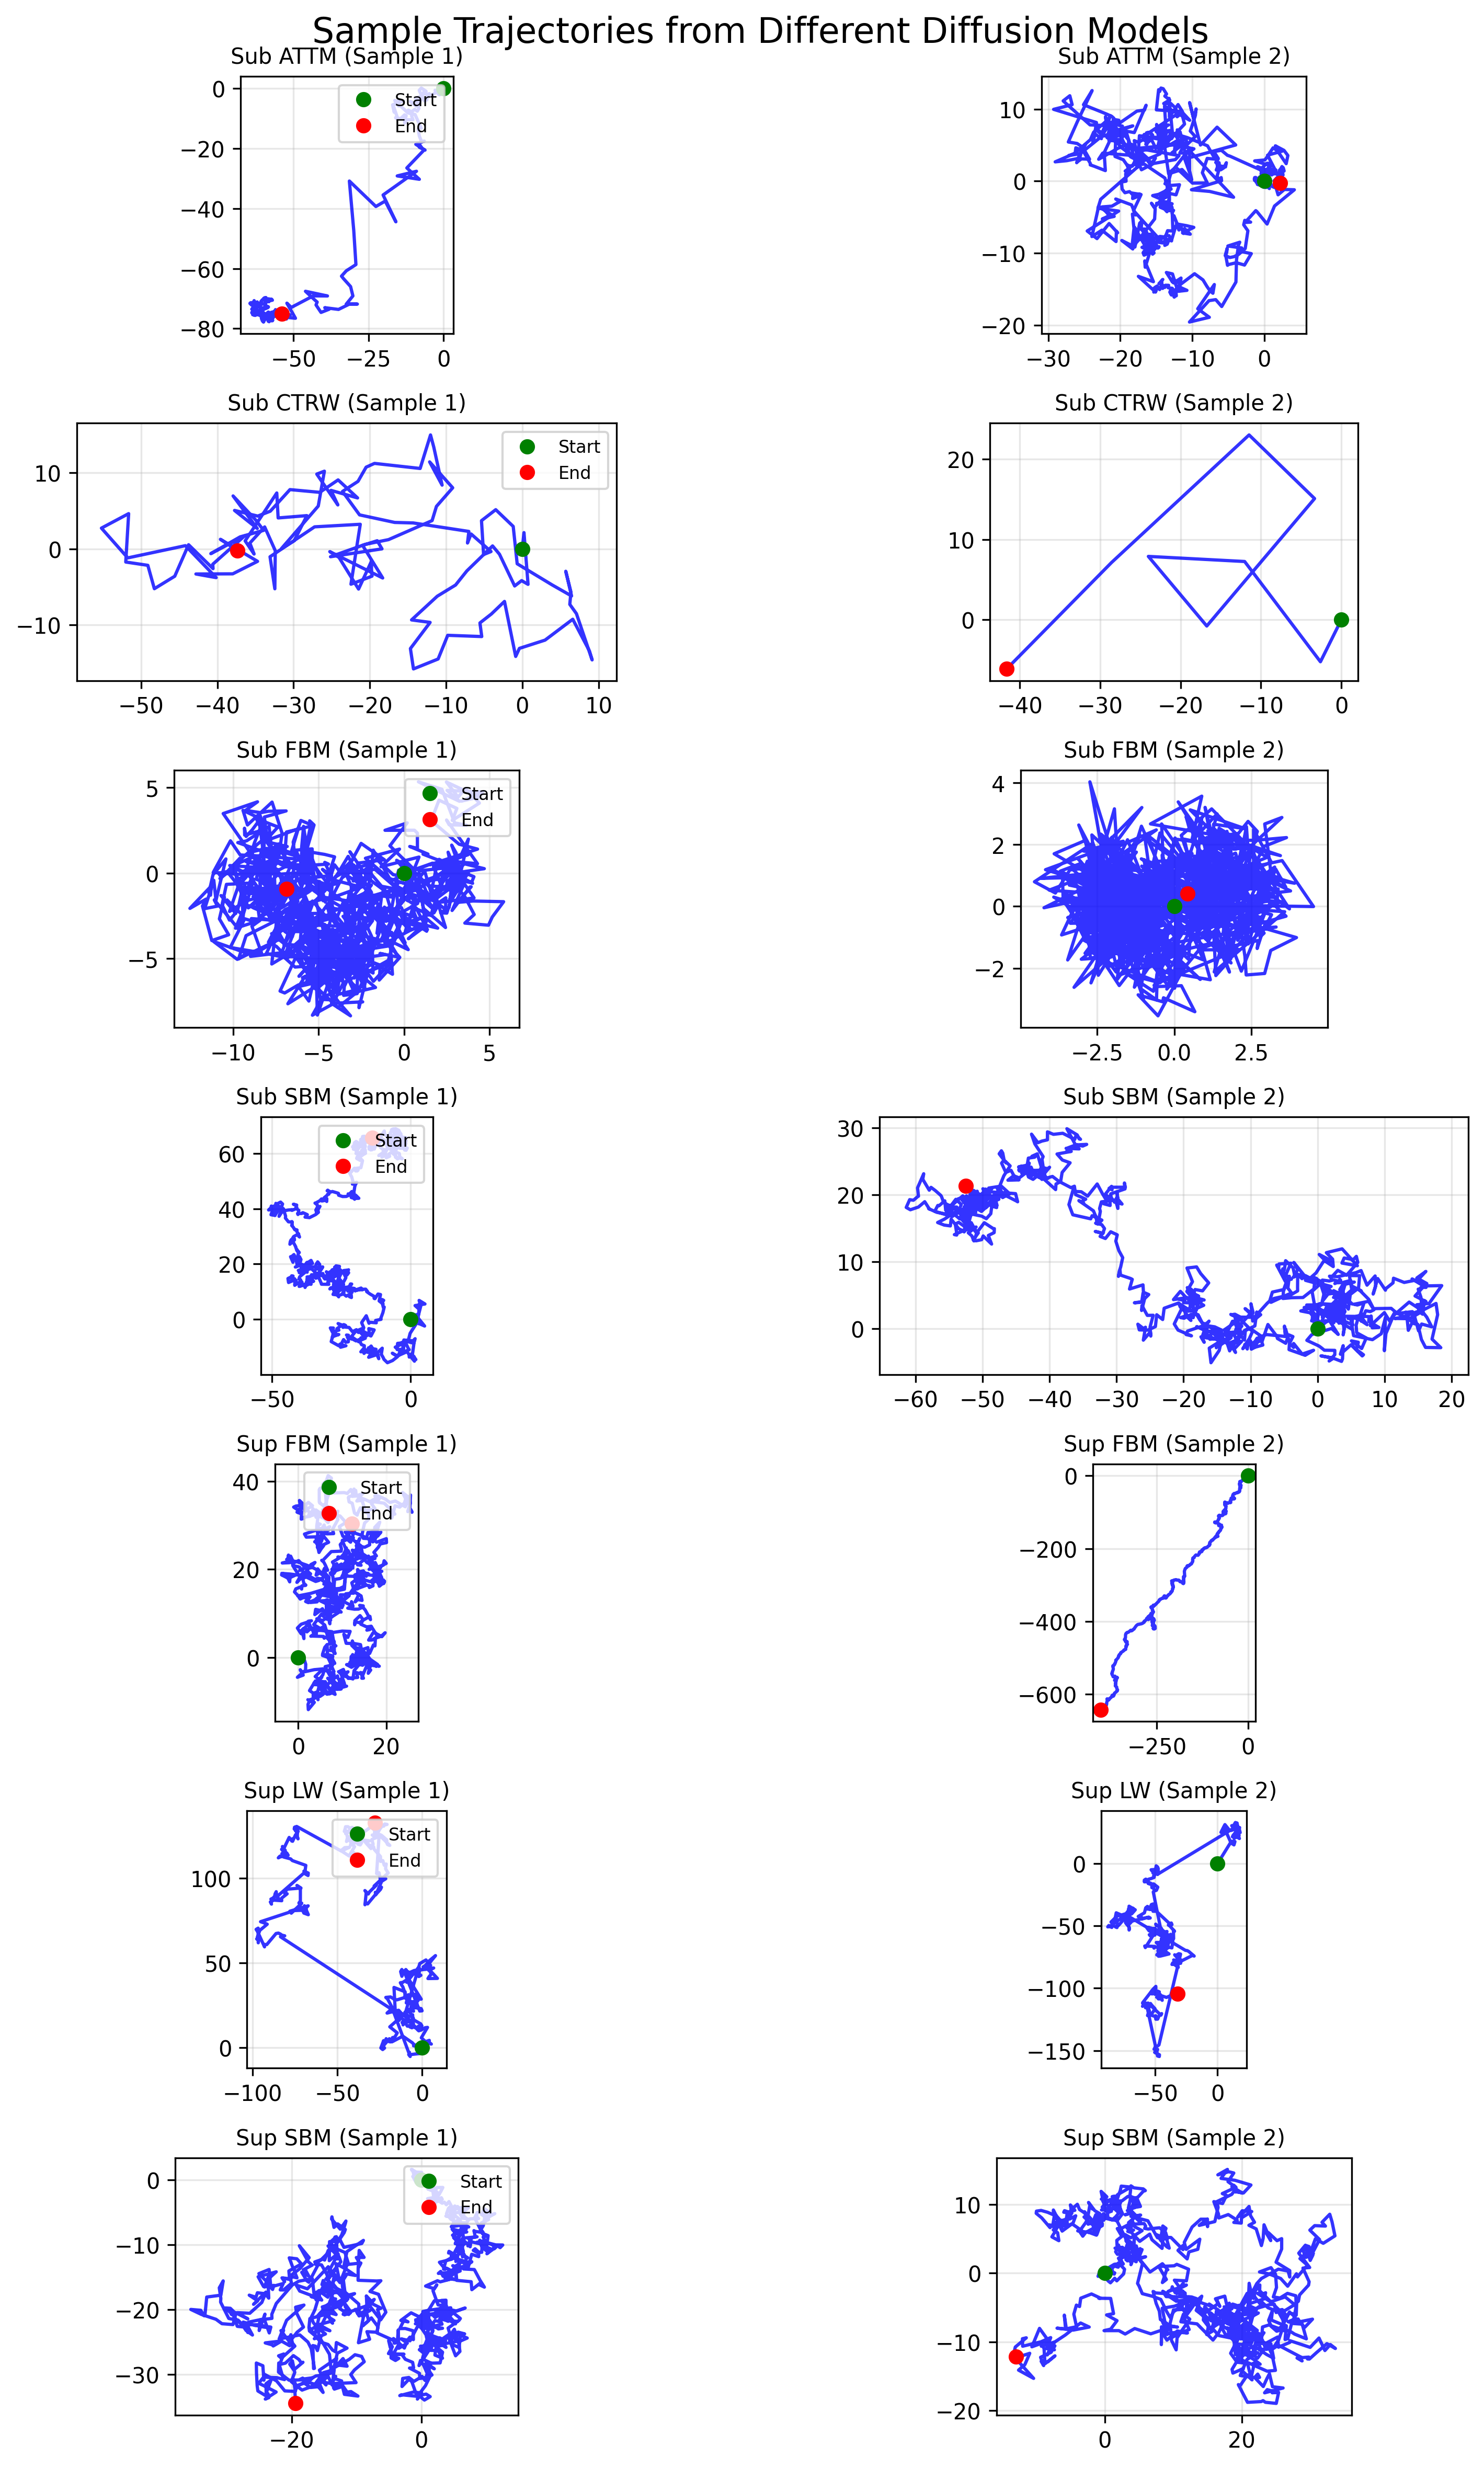

Sample visualization completed!


In [4]:
def visualize_sample_trajectories(dataset, num_samples=7, samples_per_class=2):
    """
    Visualize sample trajectories from the dataset
    """
    trajectories = dataset[0]  # trajectory data
    labels = dataset[1]       # model labels
    
    # Model names corresponding to labels
    model_names = ["Sub ATTM", "Sub CTRW", "Sub FBM", "Sub SBM", 
                   "Sup FBM", "Sup LW", "Sup SBM"]
    
    # Create figure
    fig, axes = plt.subplots(num_samples, samples_per_class, figsize=(12, 16))
    fig.suptitle('Sample Trajectories from Different Diffusion Models', fontsize=16, y=0.98)
    
    # Plot samples for each class
    for class_idx in range(num_samples):
        # Find trajectories of this class
        class_indices = np.where(np.array(labels) == class_idx)[0]
        
        if len(class_indices) == 0:
            continue
            
        # Select random samples
        selected_indices = np.random.choice(class_indices, 
                                          min(samples_per_class, len(class_indices)), 
                                          replace=False)
        
        for sample_idx, traj_idx in enumerate(selected_indices):
            if sample_idx >= samples_per_class:
                break
                
            ax = axes[class_idx, sample_idx] if num_samples > 1 else axes[sample_idx]
            
            # Get trajectory (2D: x and y coordinates)
            traj = trajectories[traj_idx][0]  # Shape: (2, T)
            x_coords = traj[0, :]
            y_coords = traj[1, :]
            
            # Plot trajectory
            ax.plot(x_coords, y_coords, 'b-', alpha=0.8, linewidth=1.5)
            ax.plot(x_coords[0], y_coords[0], 'go', markersize=6, label='Start')
            ax.plot(x_coords[-1], y_coords[-1], 'ro', markersize=6, label='End')
            
            # Styling
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
            ax.set_title(f'{model_names[class_idx]} (Sample {sample_idx+1})', fontsize=10)
            
            if sample_idx == 0:
                ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Visualize sample trajectories
print(" Visualizing sample trajectories...")
visualize_sample_trajectories(test_dataset)
print("Sample visualization completed!")

## 2. Data Preprocessing

Preprocess the generated trajectories:
- Padding to fixed length
- MinMax normalization
- Convert to PyTorch DataLoader format

In [5]:
def preprocess_datasets_in_memory(train_dataset, test_dataset, eval_dataset, batch_size=32):
    """
    Preprocess all datasets in memory
    """
    print(" Preprocessing datasets in memory...")
    
    # Preprocess training dataset
    train_dataloader = _preprocessing(train_dataset, batch_size=batch_size, shuffle=True)
    print("    Processed training dataset")
    
    # Preprocess test dataset
    test_dataloader = _preprocessing(test_dataset, batch_size=batch_size, shuffle=False)
    print("    Processed test dataset")
    
    # Preprocess eval dataset
    eval_dataloader = _preprocessing(eval_dataset, batch_size=batch_size, shuffle=False)
    print("    Processed eval dataset")
    
    return train_dataloader, test_dataloader, eval_dataloader

# Preprocess data
train_dataloader, test_dataloader, eval_dataloader = preprocess_datasets_in_memory(
    train_dataset, test_dataset, eval_dataset, DEMO_CONFIG['batch_size'])

print(f"\n Data preprocessing summary:")
print(f"   Training samples: {len(train_dataset[0])}")
print(f"   Test samples: {len(test_dataset[0])}")
print(f"   Eval samples: {len(eval_dataset[0])}")
print(f"   Batch size: {DEMO_CONFIG['batch_size']}")
print(f"   Dataset Input shape : Batchsize, 1, dimension (2), length (1000) ;  {train_dataset[0].shape}")
print("\n Data preprocessing completed!")

 Preprocessing datasets in memory...
    Processed training dataset
    Processed test dataset
    Processed eval dataset

 Data preprocessing summary:
   Training samples: 476
   Test samples: 199
   Eval samples: 120
   Batch size: 64
   Dataset Input shape : Batchsize, 1, dimension (2), length (1000) ;  (476, 1, 2, 1000)

 Data preprocessing completed!


## 3. Model Training

Train a ResNet-18 classifier on the trajectory data. The model learns to distinguish between different types of diffusion processes.

In [6]:
def train_resandi_model_in_memory(train_dataloader, eval_dataloader, num_epochs=10, lr=0.001):
    """
    Train the ResAnDi model in memory
    """
    print(f" Starting in-memory model training...")
    print(f"   Epochs: {num_epochs}")
    print(f"   Learning rate: {lr}")
    print(f"   Training batches per epoch: {len(train_dataloader)}")
    
    # Initialize model
    model = resnet18_8()
    
    # Simple training loop for demo
    import torch.nn as nn
    import torch.optim as optim
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    print(f"   Using device: {device}")
    
    # Training loop
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (data, target) in enumerate(train_dataloader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
        
        accuracy = 100 * correct / total
        avg_loss = running_loss / len(train_dataloader)

        if (epoch + 1) % 10 == 0:
            print(f"   Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss:.4f}, Train Acc: {accuracy:.2f}%")


        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_idx, (data, target) in enumerate(eval_dataloader):
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                running_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
            
            accuracy = 100 * correct / total
            avg_loss = running_loss / len(train_dataloader)


        if (epoch + 1) % 10 == 0:
            print(f"   Epoch [{epoch+1}/{num_epochs}], Eval Loss: {avg_loss:.4f}, Eval Acc: {accuracy:.2f}%")
    
    print("Model training completed!")
    return model

# Train the model in memory
model = train_resandi_model_in_memory(
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    num_epochs=DEMO_CONFIG['num_epochs'],
    lr=DEMO_CONFIG['learning_rate']
)

print("\n Model ready for analysis!")

print("Since we use demo dataset (small dataset, not optimized learning rate), evaluation & test performance may be bad.")

 Starting in-memory model training...
   Epochs: 100
   Learning rate: 0.0001
   Training batches per epoch: 8


   Using device: cuda
   Epoch [10/100], Train Loss: 0.0757, Train Acc: 97.06%
   Epoch [10/100], Eval Loss: 0.5920, Eval Acc: 44.17%
   Epoch [20/100], Train Loss: 0.0055, Train Acc: 100.00%
   Epoch [20/100], Eval Loss: 0.6883, Eval Acc: 34.17%
   Epoch [30/100], Train Loss: 0.0026, Train Acc: 100.00%
   Epoch [30/100], Eval Loss: 0.7013, Eval Acc: 41.67%
   Epoch [40/100], Train Loss: 0.0051, Train Acc: 100.00%
   Epoch [40/100], Eval Loss: 0.7049, Eval Acc: 40.00%
   Epoch [50/100], Train Loss: 0.2217, Train Acc: 94.33%
   Epoch [50/100], Eval Loss: 0.8571, Eval Acc: 31.67%
   Epoch [60/100], Train Loss: 0.0038, Train Acc: 100.00%
   Epoch [60/100], Eval Loss: 0.8822, Eval Acc: 35.00%
   Epoch [70/100], Train Loss: 0.0012, Train Acc: 100.00%
   Epoch [70/100], Eval Loss: 0.8866, Eval Acc: 35.00%
   Epoch [80/100], Train Loss: 0.0011, Train Acc: 100.00%
   Epoch [80/100], Eval Loss: 0.9309, Eval Acc: 35.00%
   Epoch [90/100], Train Loss: 0.0006, Train Acc: 100.00%
   Epoch [90/100],

## Model Performance Summary

Let's evaluate the model performance and show classification results.

Train dataset performance
 Evaluating model performance...

 Model Performance Results:
   Overall Accuracy: 100.00%
   Total Test Samples: 476

 Per-Class Accuracy:
   Sub ATTM: 100.00% (60/60)
   Sub CTRW: 100.00% (56/56)
   Sub FBM: 100.00% (60/60)
   Sub SBM: 100.00% (60/60)
   Sup FBM: 100.00% (60/60)
   Sup LW: 100.00% (60/60)
   Sup SBM: 100.00% (60/60)


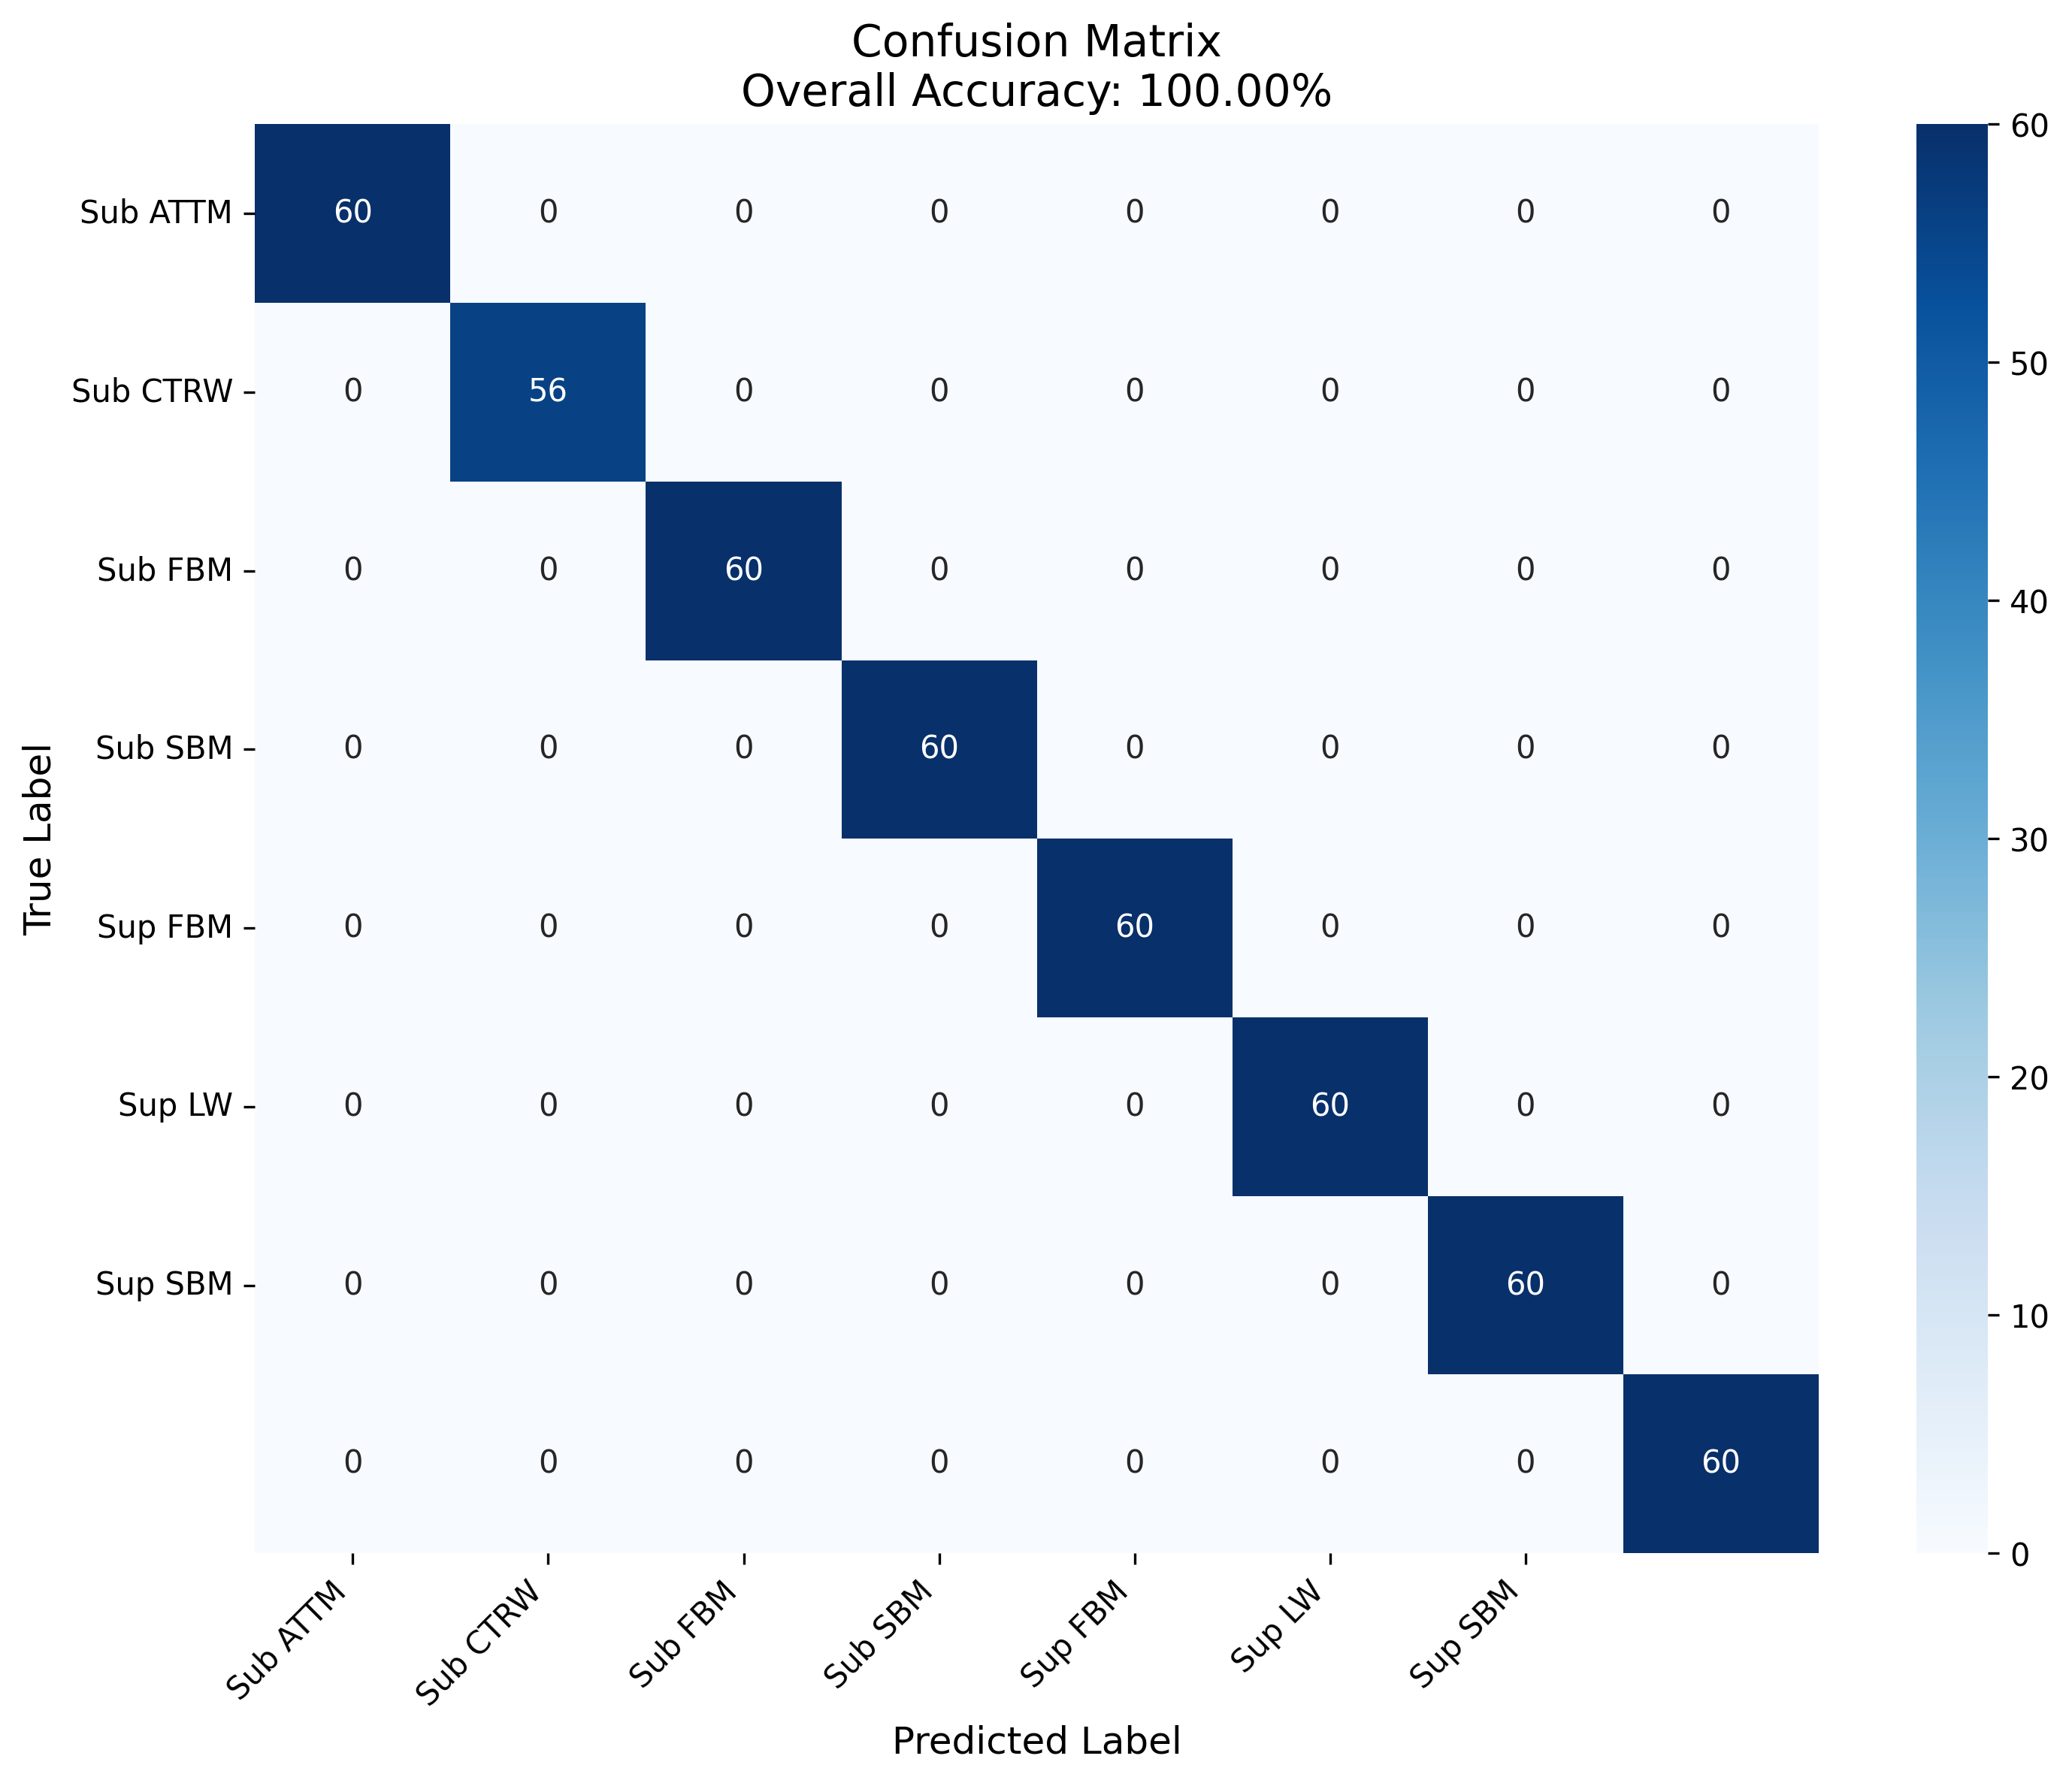

Test dataset performance
 Evaluating model performance...

 Model Performance Results:
   Overall Accuracy: 51.76%
   Total Test Samples: 199

 Per-Class Accuracy:
   Sub ATTM: 16.00% (4/25)
   Sub CTRW: 75.00% (18/24)
   Sub FBM: 88.00% (22/25)
   Sub SBM: 52.00% (13/25)
   Sup FBM: 44.00% (11/25)
   Sup LW: 64.00% (16/25)
   Sup SBM: 44.00% (11/25)


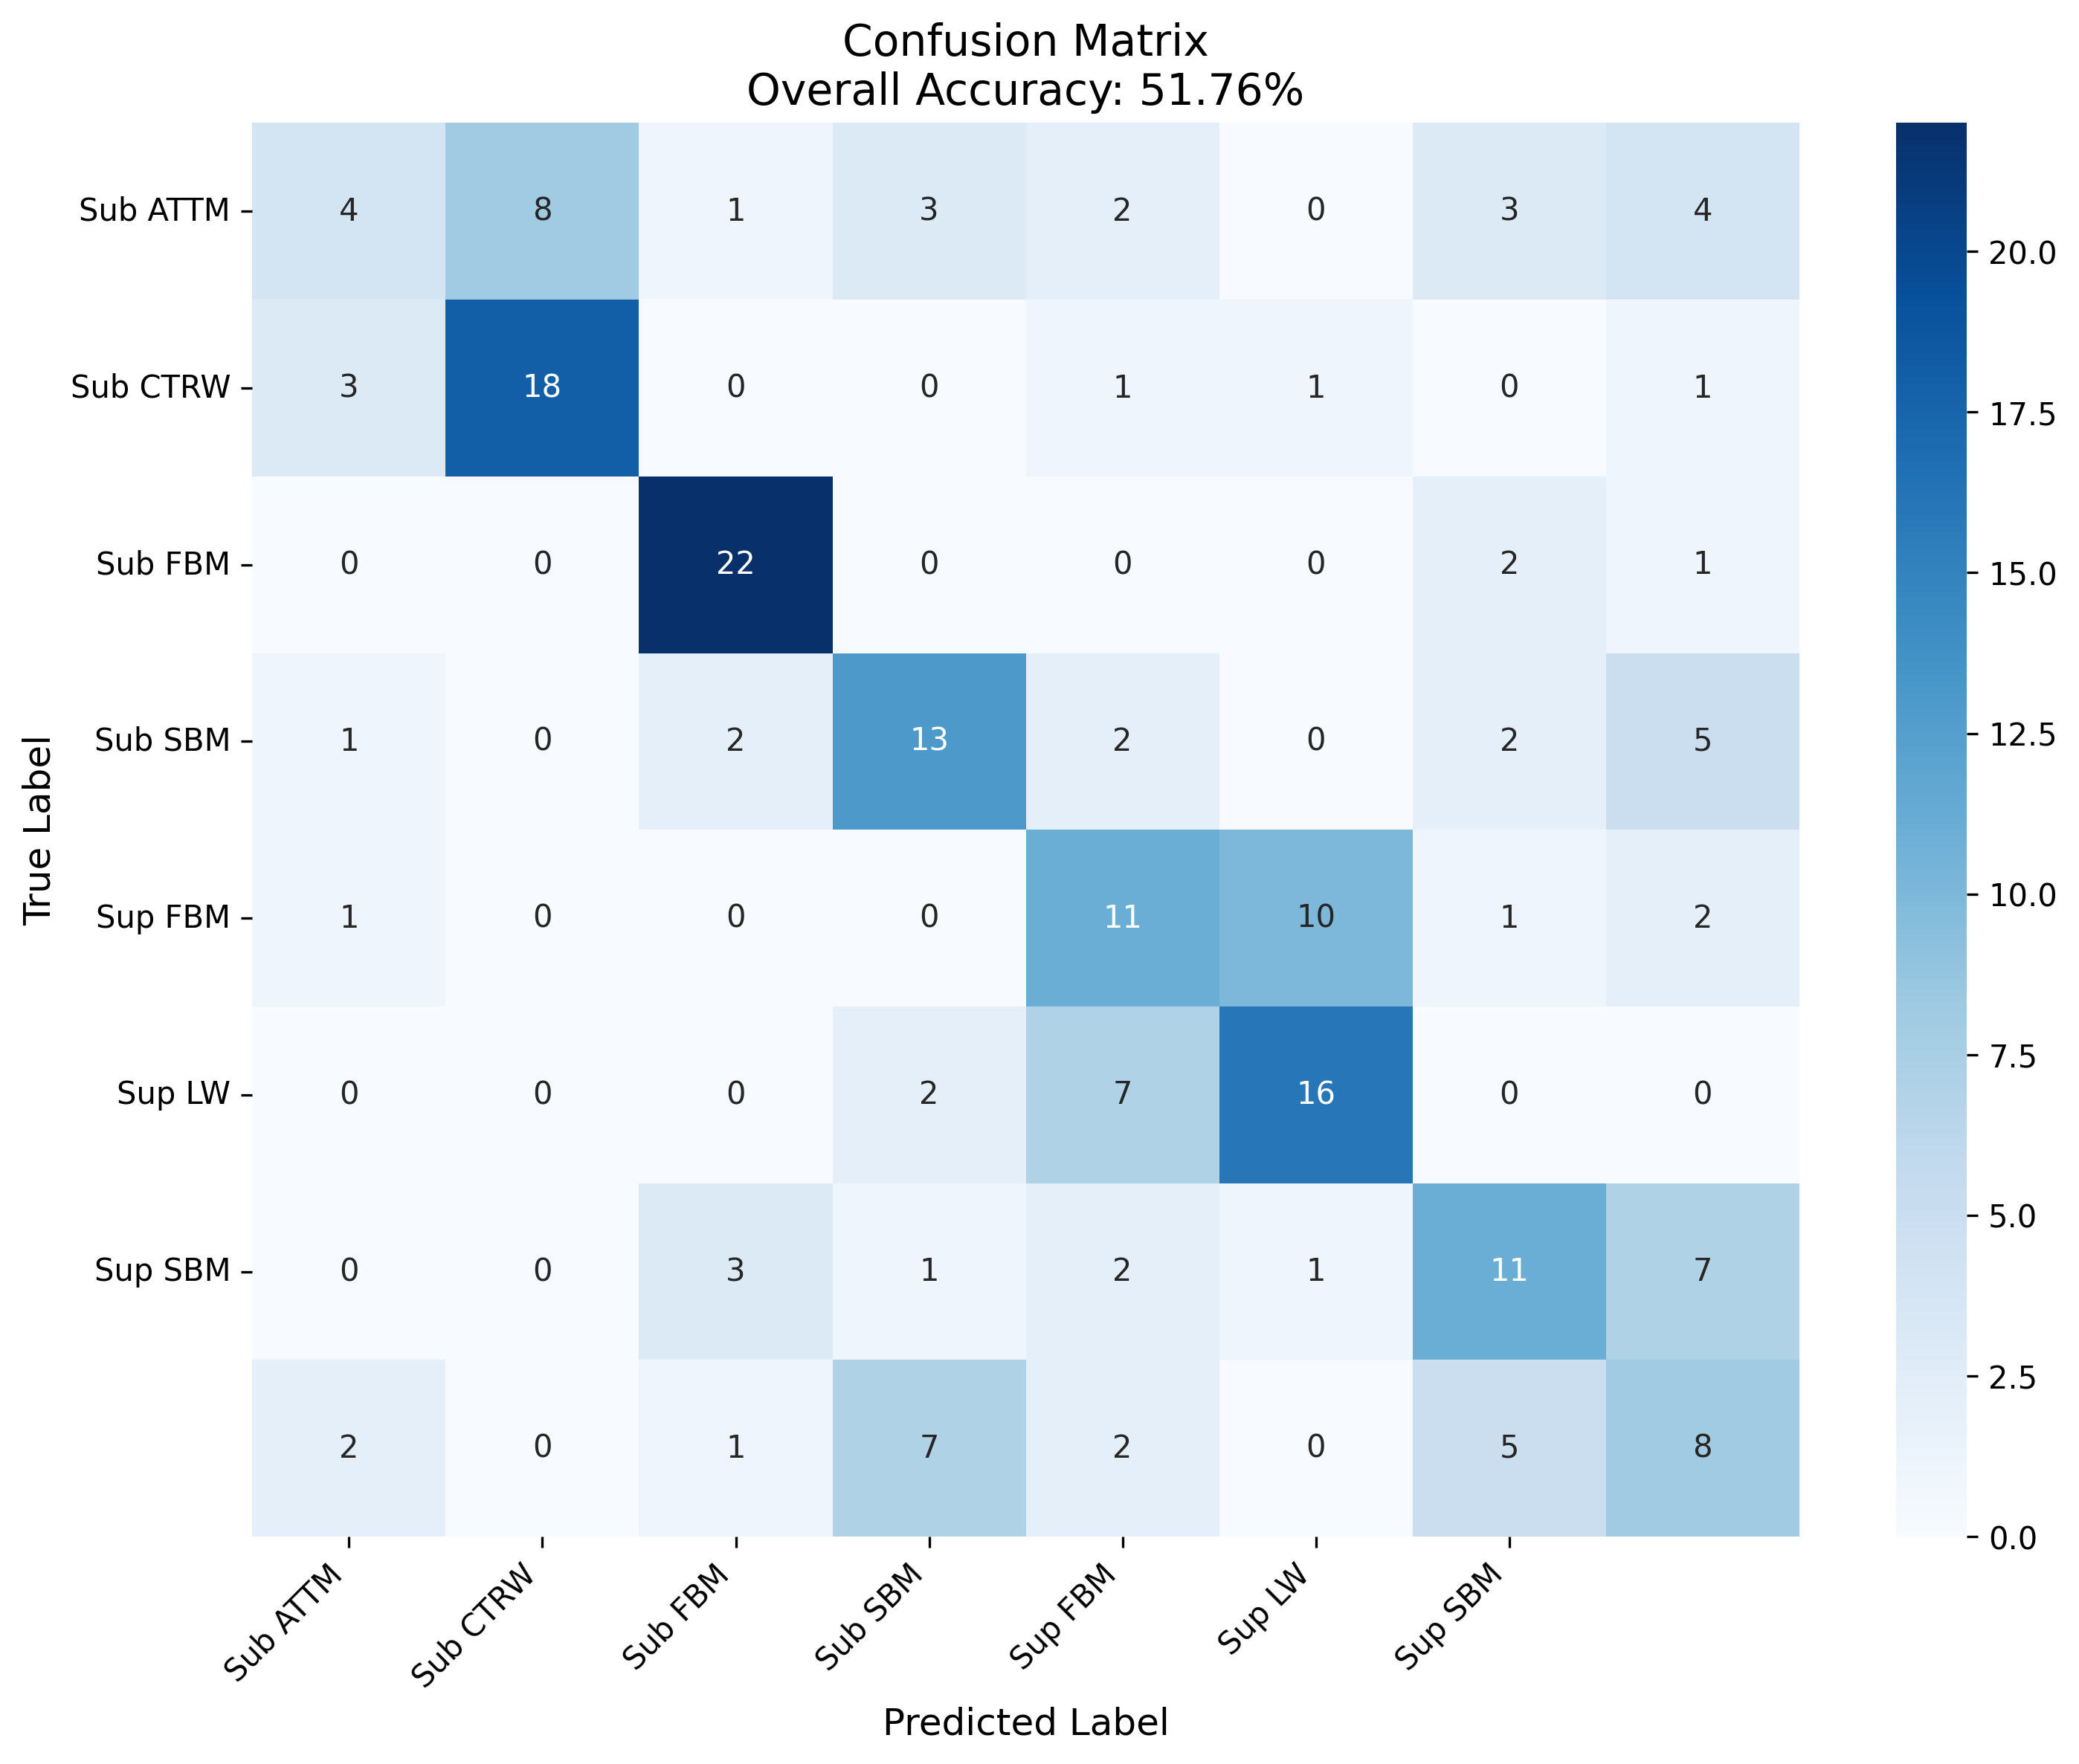


 Model evaluation completed!


In [7]:
def evaluate_model_performance(model, test_dataloader, test_dataset):
    """
    Evaluate model performance and show results
    """
    print(" Evaluating model performance...")
    
    model.eval()
    correct = 0
    total = 0
    class_correct = [0] * 8
    class_total = [0] * 8
    
    predictions = []
    true_labels = []
    # make sure model and data in same device
    device = next(model.parameters()).device

    with torch.no_grad():
        for data, labels in test_dataloader:
            data = data.to(device)
            labels = labels.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            
            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Per-class accuracy
            c = (predicted == labels).squeeze()
            for i in range(labels.size(0)):
                label = labels[i]
                class_correct[label] += c[i].item() if labels.size(0) > 1 else c.item()
                class_total[label] += 1
    
    # Overall accuracy
    overall_accuracy = 100 * correct / total
    
    # Per-class accuracy
    model_names = ["Sub ATTM", "Sub CTRW", "Sub FBM", "Sub SBM", 
                   "Sup FBM", "Sup LW", "Sup SBM"]
    
    print(f"\n Model Performance Results:")
    print(f"   Overall Accuracy: {overall_accuracy:.2f}%")
    print(f"   Total Test Samples: {total}")
    print(f"\n Per-Class Accuracy:")
    
    for i in range(len(model_names)):
        if class_total[i] > 0:
            accuracy = 100 * class_correct[i] / class_total[i]
            print(f"   {model_names[i]}: {accuracy:.2f}% ({class_correct[i]}/{class_total[i]})")
        else:
            print(f"   {model_names[i]}: No samples")
    
    # Create confusion matrix visualization
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    
    cm = confusion_matrix(true_labels, predictions)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model_names, yticklabels=model_names)
    plt.title(f'Confusion Matrix\nOverall Accuracy: {overall_accuracy:.2f}%', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    return overall_accuracy, class_correct, class_total

# Evaluate model performance
try:
    print("Train dataset performance")
    accuracy, class_correct, class_total = evaluate_model_performance(model, train_dataloader, train_dataset)
    print("Test dataset performance")
    accuracy, class_correct, class_total = evaluate_model_performance(model, test_dataloader, test_dataset)
    print("\n Model evaluation completed!")
except Exception as e:
    print(f" Error in model evaluation: {str(e)}")

## 4. 🔍 Grad-CAM Analysis

Generate Gradient-weighted Class Activation Maps (Grad-CAM) to understand which parts of trajectories are most important for classification.

In [8]:
def generate_gradcam_in_memory(model, test_dataloader, num_samples=200):
    """
    Generate Grad-CAM analysis in memory using Captum
    """
    print(" Generating Grad-CAM analysis in memory...")
    
    try:
        from captum.attr import LayerGradCam
        from captum.attr import LayerAttribution
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
        model.eval()
        
        # Create GradCAM instance
        gradcam = LayerGradCam(model, model.layer4)
        
        attributions = []
        sampled_dim = 1000
        samples_processed = 0
        
        print(f"   Using device: {device}")
        
        with torch.no_grad():
            for batch_idx, (X, y) in enumerate(test_dataloader):
                if samples_processed >= num_samples:
                    break
                    
                inputs = X.to(device)
                target = y.to(device)
                
                # Generate attribution
                attribution = gradcam.attribute(inputs=inputs, target=target)
                attribution = torch.squeeze(attribution, -2)
                
                # Interpolate to desired dimension
                attribution = LayerAttribution.interpolate(
                    attribution, sampled_dim, interpolate_mode="nearest"
                )
                
                # Convert to list and extend
                batch_attributions = torch.squeeze(attribution).cpu().tolist()
                if isinstance(batch_attributions[0], list):
                    attributions.extend(batch_attributions)
                else:
                    attributions.append(batch_attributions)
                
                samples_processed += len(X)
                
                if batch_idx % 5 == 0:
                    print(f"   Processed {samples_processed}/{num_samples} samples")
        
        # Clear GPU memory
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        
        print(" Grad-CAM analysis completed!")
        return np.array(attributions[:num_samples])
        
    except ImportError:
        print(" Captum not available, using simplified Grad-CAM...")
        return generate_simple_gradcam(model, test_dataloader, num_samples)
    except Exception as e:
        print(f" Error in Grad-CAM analysis: {str(e)}")
        print("   Using dummy attribution data for visualization")
        return np.random.rand(num_samples, 1000)

def generate_simple_gradcam(model, test_dataloader, num_samples):
    """
    Simple Grad-CAM implementation without Captum
    """
    device = next(model.parameters()).device
    model.eval()
    
    attributions = []
    samples_processed = 0
    
    for X, y in test_dataloader:
        if samples_processed >= num_samples:
            break
            
        inputs = X.to(device)
        inputs.requires_grad_(True)
        
        # Forward pass
        outputs = model(inputs)
        pred_classes = outputs.argmax(dim=1)
        
        # Backward pass for each sample
        for i in range(len(inputs)):
            if samples_processed >= num_samples:
                break
                
            model.zero_grad()
            class_score = outputs[i, pred_classes[i]]
            class_score.backward(retain_graph=True)
            
            # Simple gradient-based attribution
            gradients = inputs.grad[i].abs().mean(dim=(0, 1)).cpu().numpy()
            attributions.append(gradients)
            samples_processed += 1
    
    return np.array(attributions)

# Generate Grad-CAM for train dataset
gradcam_results = generate_gradcam_in_memory(
    model, 
    train_dataloader, 
    num_samples=len(train_dataset[0])
)

print(" Grad-CAM analysis ready!")

 Generating Grad-CAM analysis in memory...
   Using device: cuda
   Processed 64/476 samples
   Processed 384/476 samples
 Grad-CAM analysis completed!
 Grad-CAM analysis ready!


## 5. Grad-CAM and Trajectory Visualization

Visualize trajectories overlaid with Grad-CAM attribution values to see which time points are most important for classification.

 Creating Grad-CAM visualization...


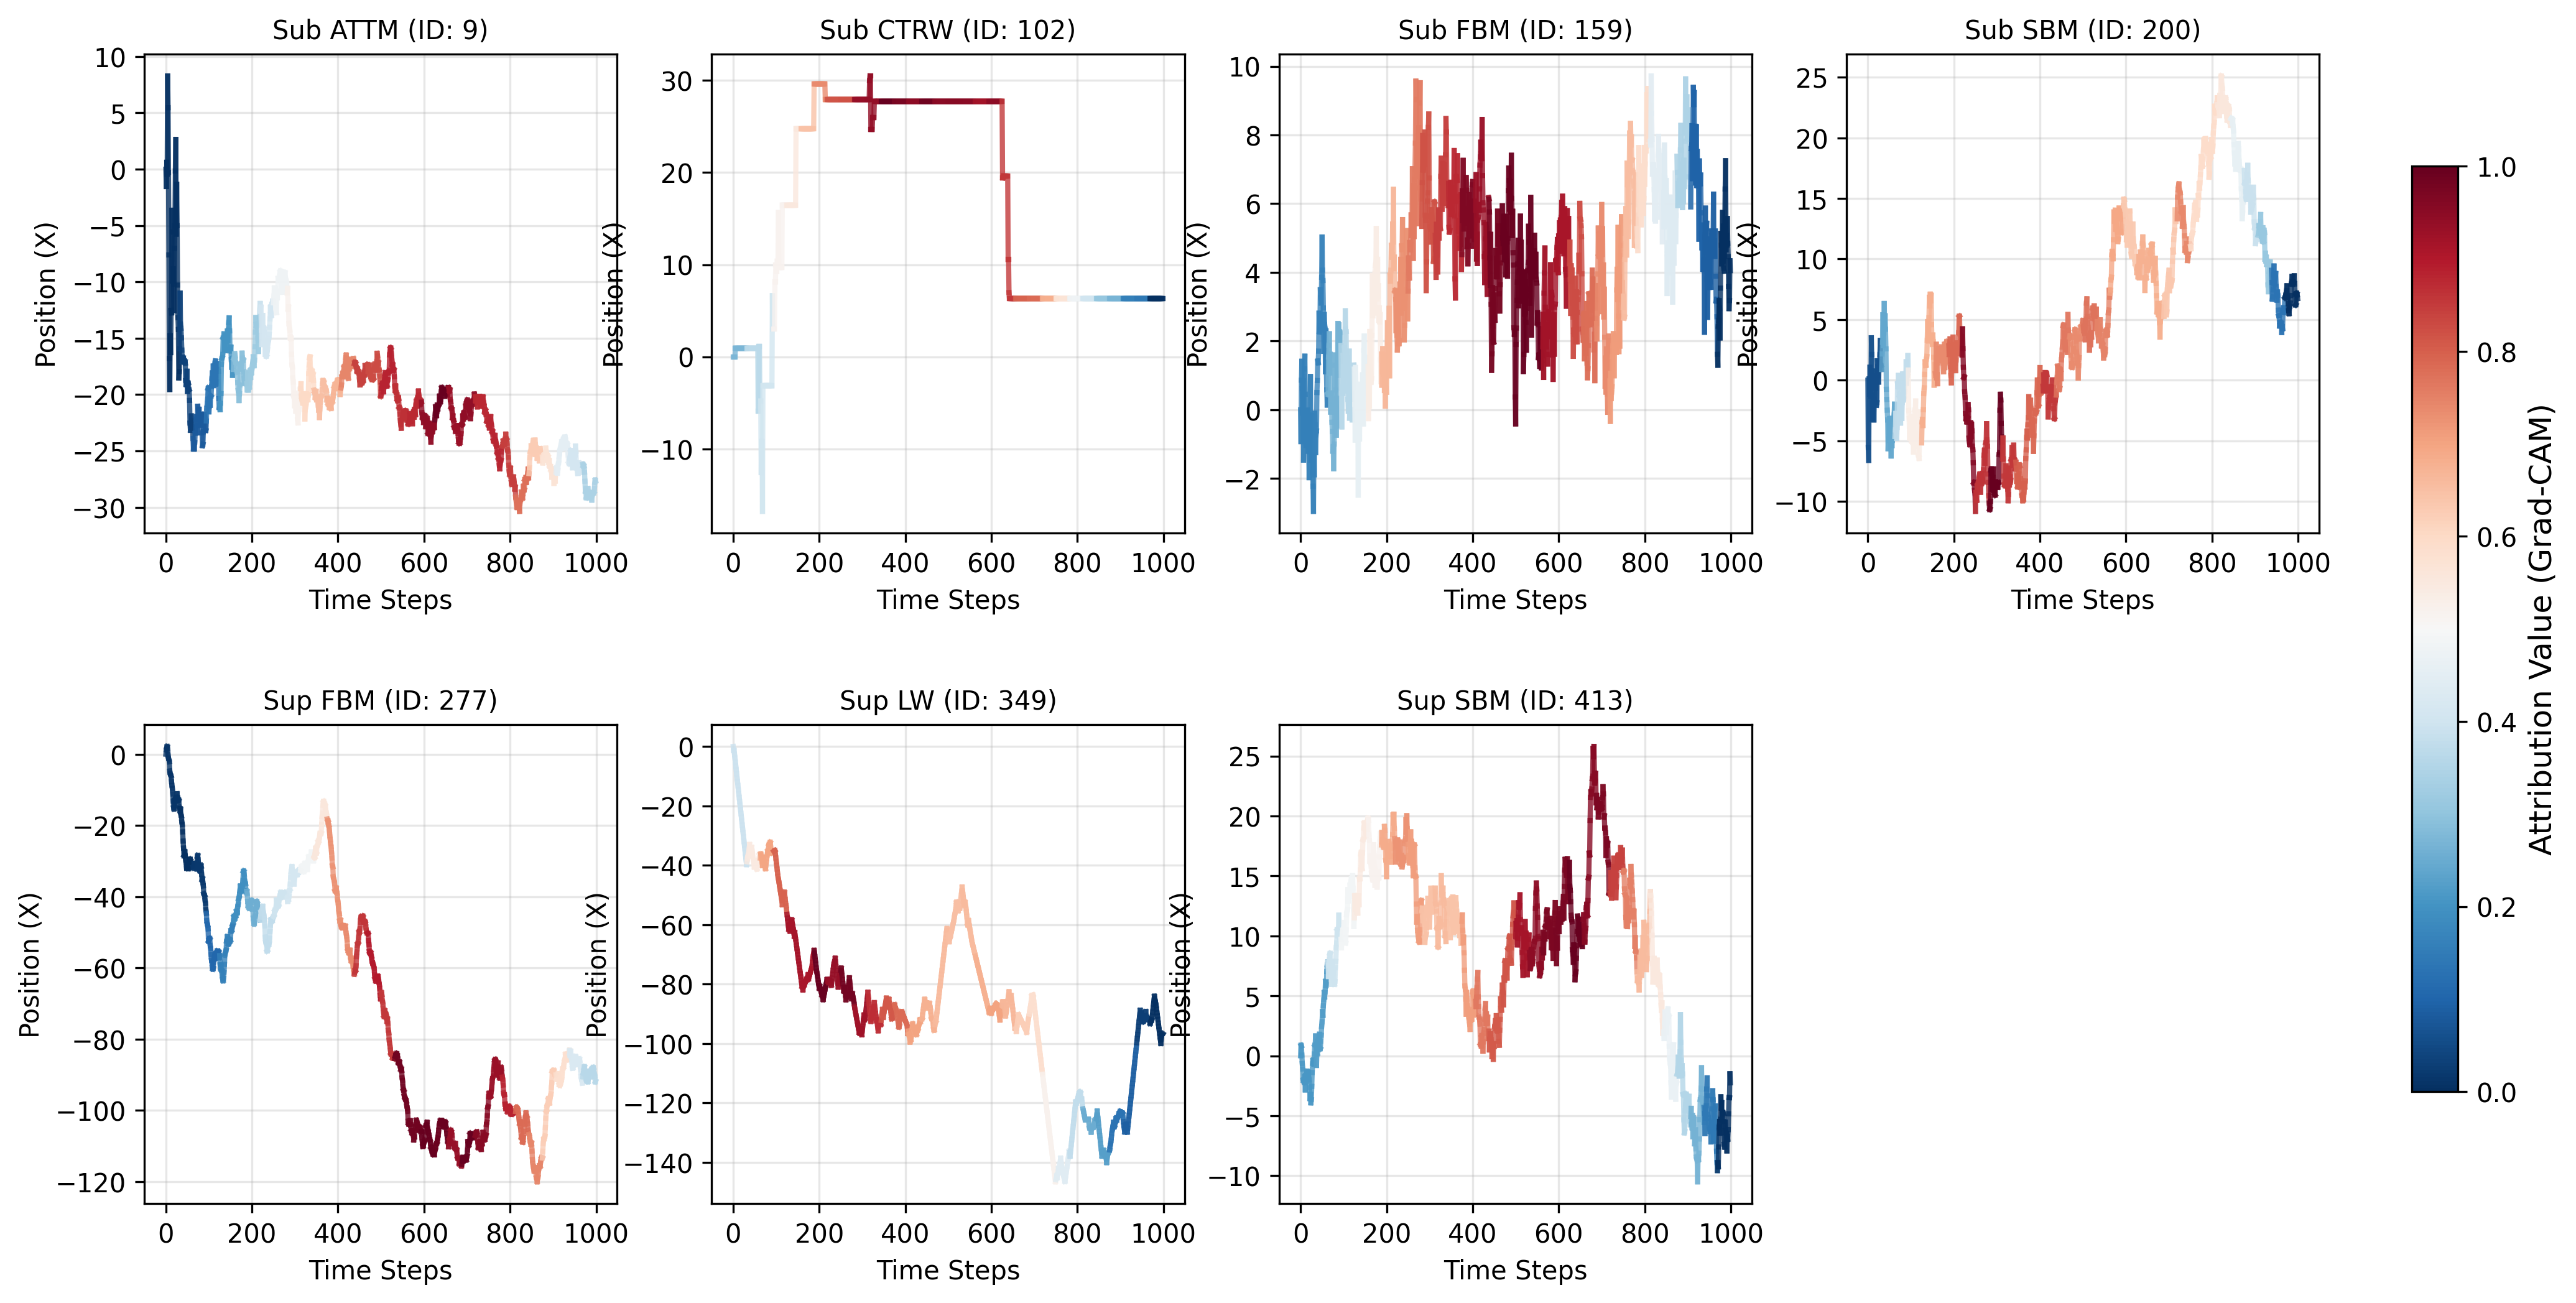

 Grad-CAM visualization completed!


In [9]:
def visualize_gradcam_trajectories_in_memory(dataset, gradcam_data, num_samples=12):
    """
    Visualize trajectories with Grad-CAM overlays from in-memory data
    """
    print(" Creating Grad-CAM visualization...")
    
    try:
        # Model names
        model_names = ["Sub ATTM", "Sub CTRW", "Sub FBM", "Sub SBM", 
                       "Sup FBM", "Sup LW", "Sup SBM"]
        
        # Select sample indices (distribute across classes)
        labels = np.array(dataset[1])
        sample_indices = []
        
        samples_per_class = max(1, num_samples // len(model_names))
        for class_idx in range(len(model_names)):
            class_indices = np.where(labels == class_idx)[0]
            if len(class_indices) > 0:
                selected = np.random.choice(class_indices, 
                                          min(samples_per_class, len(class_indices)), 
                                          replace=False)
                sample_indices.extend(selected)
        
        sample_indices = sample_indices[:num_samples]
        
        # Create visualization
        cols = 4
        rows = (len(sample_indices) + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
        # make h space in subplots
        fig.subplots_adjust(hspace=0.4)
        fig.subplots_adjust(wspace=0.2)
        if rows == 1:
            axes = axes.reshape(1, -1)
        
        # Color map for attribution values
        cmap = plt.get_cmap('RdBu_r')
        
        for i, idx in enumerate(sample_indices):
            if idx >= len(gradcam_data):
                continue
                
            row, col = i // cols, i % cols
            ax = axes[row, col]
            
            # Get trajectory data
            trajectory = dataset[0][idx][0]  # Shape: (2, T)
            x_coords = trajectory[0, :]
            
            # Get attribution values and normalize
            attribution = gradcam_data[idx]
            if len(attribution) > len(x_coords):
                attribution = attribution[:len(x_coords)]
            elif len(attribution) < len(x_coords):
                # Pad with zeros if needed
                attribution = np.pad(attribution, (0, len(x_coords) - len(attribution)))
            
            attribution_norm = MinMaxScaler().fit_transform(attribution.reshape(-1, 1)).flatten()
            
            # Plot trajectory with color-coded attribution
            for t in range(len(x_coords) - 1):
                color = cmap(attribution_norm[t] if t < len(attribution_norm) else 0.5)
                ax.plot([t, t+1], [x_coords[t], x_coords[t+1]], 
                       color=color, linewidth=2, alpha=0.8)
            
            # Styling
            ax.set_title(f'{model_names[int(labels[idx])]} (ID: {idx})', fontsize=10)
            ax.set_xlabel('Time Steps')
            ax.set_ylabel('Position (X)')
            ax.grid(True, alpha=0.3)
        
        # Hide unused subplots
        for i in range(len(sample_indices), rows * cols):
            row, col = i // cols, i % cols
            axes[row, col].set_visible(False)
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes, orientation='vertical', 
                           fraction=0.02, pad=0.04)
        cbar.set_label('Attribution Value (Grad-CAM)', fontsize=12)
        
        # plt.tight_layout()
        plt.show()
        
        return fig
        
    except Exception as e:
        print(f" Error in Grad-CAM visualization: {str(e)}")
        return None

# Visualize Grad-CAM results
if gradcam_results is not None:
    visualize_gradcam_trajectories_in_memory(train_dataset, gradcam_results, num_samples=12)
    print(" Grad-CAM visualization completed!")
else:
    print(" Skipping Grad-CAM visualization due to analysis error")

## 6. t-SNE Analysis and Visualization

Perform t-SNE dimensionality reduction on learned features to visualize how well the model separates different diffusion model classes.

 Extracting features for t-SNE...
   Processed 320/300 samples
    Extracted features shape: (300, 512)
 Performing t-SNE analysis...
    t-SNE completed. Shape: (300, 2)
 Creating t-SNE visualization...


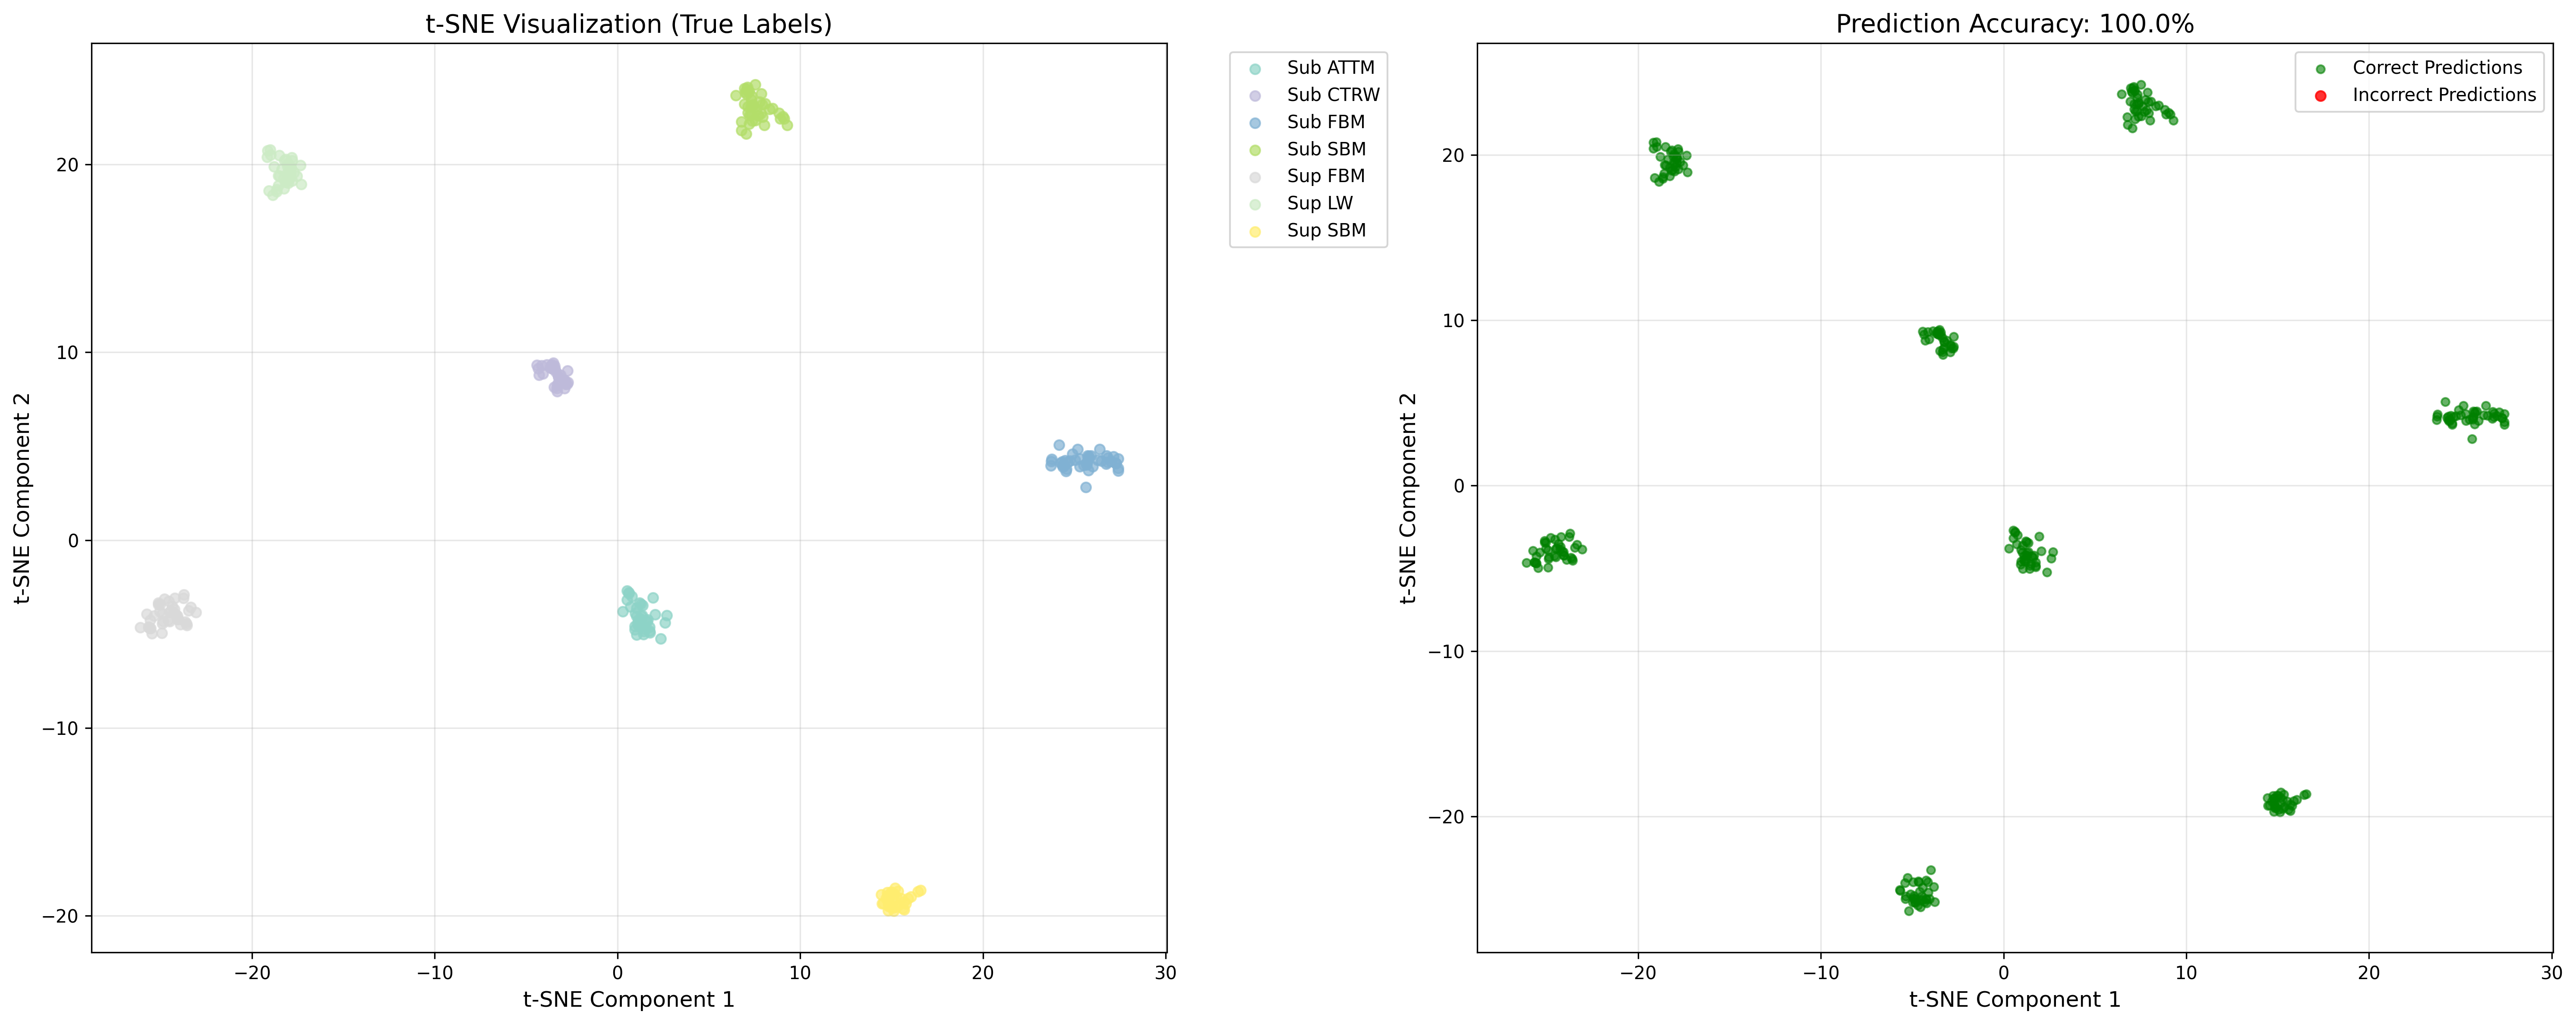

 t-SNE analysis completed!


In [10]:
def extract_features_for_tsne_proper(model, dataloader, max_samples=500):
    """
    Extract features from the model for t-SNE analysis using proper hook method
    """
    print(" Extracting features for t-SNE...")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    # Feature storage
    features = {}
    all_features = []
    all_labels = []
    all_predictions = []
    
    # Hook function to capture features
    def get_features(name):
        def hook(model, input, output):
            features[name] = output.detach()
        return hook
    
    # Register hooks for different layers
    avgpool = torch.nn.AdaptiveAvgPool2d((1, 1))
    hook_handle = model.layer4.register_forward_hook(get_features('layer4'))
    
    samples_processed = 0
    
    with torch.no_grad():
        for batch_idx, (X, y) in enumerate(dataloader):
            if samples_processed >= max_samples:
                break
                
            inputs = X.to(device)
            labels = y.to(device)
            
            # Forward pass
            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=-1)
            
            # Extract features from layer4
            if 'layer4' in features:
                batch_features = avgpool(features['layer4'])
                batch_features = torch.flatten(batch_features, 1)
                
                all_features.append(batch_features.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
                all_predictions.append(predictions.cpu().numpy())
                
                samples_processed += len(X)

        print(f"   Processed {samples_processed}/{max_samples} samples")
    
    # Remove hook
    hook_handle.remove()
    
    # Concatenate all features
    features_array = np.vstack(all_features)[:max_samples]
    labels_array = np.concatenate(all_labels)[:max_samples]
    predictions_array = np.concatenate(all_predictions)[:max_samples]
    
    print(f"    Extracted features shape: {features_array.shape}")
    return features_array, labels_array, predictions_array

def perform_tsne_analysis_proper(features, labels, n_components=2, random_state=42):
    """
    Perform t-SNE dimensionality reduction
    """
    print(" Performing t-SNE analysis...")
    
    # Apply t-SNE
    perplexity = min(30, len(features)//4)
    tsne = TSNE(n_components=n_components, 
                random_state=random_state, 
                perplexity=perplexity,
                max_iter=1000)
    
    features_tsne = tsne.fit_transform(features)

    print(f"    t-SNE completed. Shape: {features_tsne.shape}")
    return features_tsne

def visualize_tsne_results_proper(features_tsne, labels, predictions=None):
    """
    Visualize t-SNE results with proper model names
    """
    print(" Creating t-SNE visualization...")
    
    # Model names (7 classes based on dataset generation)
    model_names = ["Sub ATTM", "Sub CTRW", "Sub FBM", "Sub SBM", 
                   "Sup FBM", "Sup LW", "Sup SBM"]
    
    # Colors for each class
    colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Colored by true labels
    for class_idx in range(len(model_names)):
        mask = labels == class_idx
        if np.any(mask):
            ax1.scatter(features_tsne[mask, 0], features_tsne[mask, 1], 
                       c=[colors[class_idx]], label=model_names[class_idx], 
                       alpha=0.7, s=30)
    
    ax1.set_xlabel('t-SNE Component 1', fontsize=12)
    ax1.set_ylabel('t-SNE Component 2', fontsize=12)
    ax1.set_title('t-SNE Visualization (True Labels)', fontsize=14)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Show prediction accuracy if available
    if predictions is not None:
        correct_mask = labels == predictions
        incorrect_mask = ~correct_mask
        
        # Plot correct predictions
        ax2.scatter(features_tsne[correct_mask, 0], features_tsne[correct_mask, 1], 
                   c='green', alpha=0.6, s=20, label='Correct Predictions')
        
        # Plot incorrect predictions
        ax2.scatter(features_tsne[incorrect_mask, 0], features_tsne[incorrect_mask, 1], 
                   c='red', alpha=0.8, s=30, label='Incorrect Predictions')
        
        accuracy = np.mean(correct_mask) * 100
        ax2.set_title(f'Prediction Accuracy: {accuracy:.1f}%', fontsize=14)
    else:
        # Just color by class if no predictions
        for class_idx in range(len(model_names)):
            mask = labels == class_idx
            if np.any(mask):
                ax2.scatter(features_tsne[mask, 0], features_tsne[mask, 1], 
                           c=[colors[class_idx]], alpha=0.7, s=30)
        ax2.set_title('t-SNE Visualization (Clustered)', fontsize=14)
    
    ax2.set_xlabel('t-SNE Component 1', fontsize=12)
    ax2.set_ylabel('t-SNE Component 2', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Perform t-SNE analysis
try:
    # Extract features using proper method
    features, labels, predictions = extract_features_for_tsne_proper(
        model, train_dataloader, max_samples=300
    )
    
    # Perform t-SNE
    features_tsne = perform_tsne_analysis_proper(features, labels)
    
    # Visualize results
    visualize_tsne_results_proper(features_tsne, labels, predictions)
    
    print(" t-SNE analysis completed!")
    
except Exception as e:
    print(f"Error in t-SNE analysis: {str(e)}")
    print("This might be due to insufficient data or model issues.")